# Customer Churn Prediction
Pipeline: **SQL (cleaning + business split) → Python (EDA, features, model) → Power BI (stakeholder reporting)**.
Each layer owns one job — this notebook consumes the *already-cleaned* `vw_churndata` / `vw_joindata` views (produced by `null.sql` + `analysis.sql`) and does not re-clean them.

## 1. Imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
sns.set_style("whitegrid")

## 2. Load Data
Loaded straight from the SQL-cleaned view. A quick assertion confirms the SQL cleaning actually landed — if this fails, the pipeline handoff is broken and needs fixing upstream, not patched here.

In [21]:
data = pd.read_excel(r"C:\Users\ANURAG\Desktop\projects\Churn Analysis & Prediction\prediction_for_python.xlsx", sheet_name="vw_churndata", keep_default_na=False, na_values=[""])
data.columns = data.columns.str.title()

assert data[["Value_Deal", "Internet_Type"]].isnull().sum().sum() == 0, "SQL cleaning didn't apply — check the source export"
print(data.shape)
data["Customer_Status"].value_counts(normalize=True).round(3)

(6007, 32)


Customer_Status
Stayed     0.712
Churned    0.288
Name: proportion, dtype: float64

## 3. Data Quality Check
One check SQL doesn't cover: invalid numeric values. Everything else (nulls, the churned/stayed split) is already handled upstream in SQL.

In [22]:
neg_charges = (data["Monthly_Charge"] < 0).sum()
print(f"Negative Monthly_Charge rows: {neg_charges}")
data["Monthly_Charge"] = data["Monthly_Charge"].clip(lower=0)

Negative Monthly_Charge rows: 101


## 4. EDA — What Drives Churn

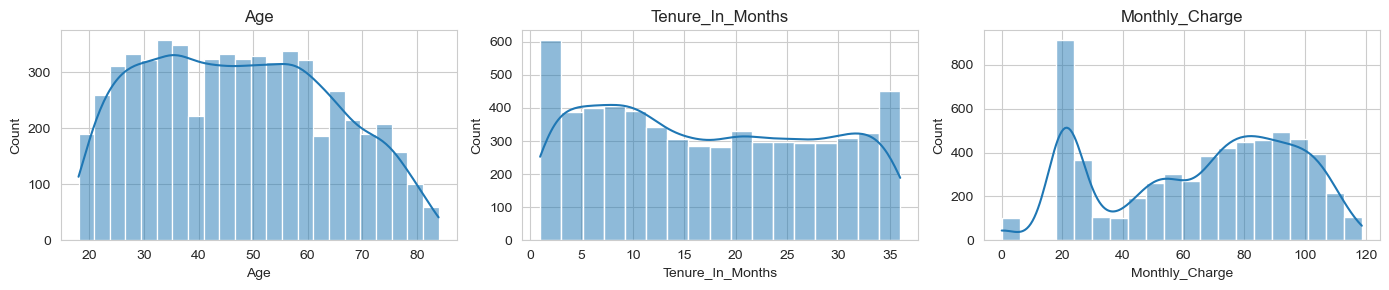

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, col in zip(axes, ["Age", "Tenure_In_Months", "Monthly_Charge"]):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

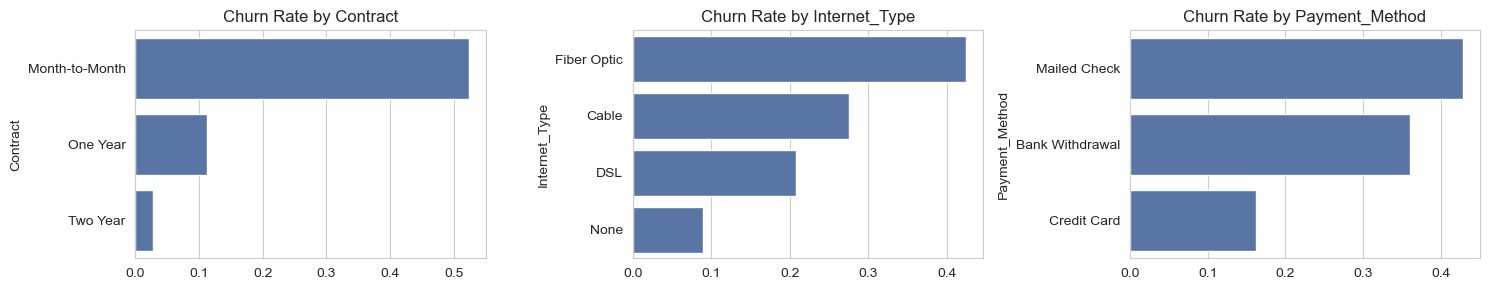

In [24]:
def churn_rate(col):
    return data.groupby(col)["Customer_Status"].apply(lambda s: (s == "Churned").mean()).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, col in zip(axes, ["Contract", "Internet_Type", "Payment_Method"]):
    r = churn_rate(col)
    sns.barplot(x=r.values, y=r.index, ax=ax, color="#4c72b0")
    ax.set_title(f"Churn Rate by {col}")
plt.tight_layout(); plt.show()

**Insight (feeds the Power BI narrative directly):** Month-to-Month contracts and Fiber Optic internet show the highest churn rates — the same story the dashboard tells, now with the effect size quantified for the model.

## 5. Feature Engineering
A few features the raw columns don't give you directly.

In [25]:
service_cols = ["Online_Security","Online_Backup","Device_Protection_Plan","Premium_Support",
                "Streaming_Tv","Streaming_Movies","Streaming_Music","Unlimited_Data"]

data["Total_Services"] = (data[service_cols] == "Yes").sum(axis=1)
data["Revenue_Per_Month"] = data["Total_Revenue"] / data["Tenure_In_Months"].replace(0, 1)
data["Has_Promo"] = (data["Value_Deal"] != "None").astype(int)

## 6. Encode + Split (stratified)

In [26]:
model_data = data.drop(columns=["Customer_Id", "Churn_Category", "Churn_Reason"])
model_data["Customer_Status"] = model_data["Customer_Status"].map({"Stayed": 0, "Churned": 1})

encoders = {}
for col in model_data.select_dtypes(include="object").columns:
    encoders[col] = LabelEncoder()
    model_data[col] = encoders[col].fit_transform(model_data[col])

X, y = model_data.drop("Customer_Status", axis=1), model_data["Customer_Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 7. Balance Training Data (SMOTE, train-only)

In [27]:
X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)
print(y_train.value_counts().to_dict(), "->", y_train_sm.value_counts().to_dict())

{0: 3420, 1: 1385} -> {0: 3420, 1: 3420}


## 8. Compare Models (recall-focused — a missed churner costs more than a false alarm)

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    score = cross_val_score(
        model,
        X_train_sm,
        y_train_sm,
        cv=cv,
        scoring="recall"
    ).mean()
    
    print(f"{name}: Recall = {score:.3f}")

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

Logistic Regression: Recall = 0.832
Random Forest: Recall = 0.888
XGBoost: Recall = 0.883


## 9. Train Final Model + Evaluate

In [29]:
best_model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42)
best_model.fit(X_train_sm, y_train_sm)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

[[755 100]
 [ 91 256]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       855
           1       0.72      0.74      0.73       347

    accuracy                           0.84      1202
   macro avg       0.81      0.81      0.81      1202
weighted avg       0.84      0.84      0.84      1202

ROC-AUC: 0.888


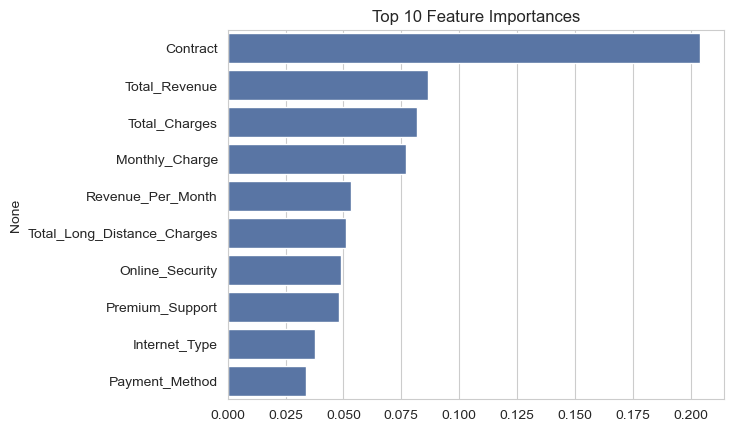

In [30]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importances.values[:10], y=importances.index[:10], color="#4c72b0")
plt.title("Top 10 Feature Importances"); plt.show()

## 10. Save Model

In [31]:
with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump({"model": best_model, "feature_names": X.columns.tolist(), "encoders": encoders}, f)
print("saved")

saved


## 11. Score Active Customers (`vw_joindata`) — Feeds Power BI
This becomes the source table for the dashboard's "Customers at Risk" visuals — Power BI reads the CSV below, so the dashboard reflects the same model and features as this notebook, not a stale prior run.

In [32]:
new = pd.read_excel(r"C:\Users\ANURAG\Desktop\projects\Churn Analysis & Prediction\prediction_for_python.xlsx", sheet_name="vw_joindata", keep_default_na=False, na_values=[""])
new.columns = new.columns.str.title()
out = new.copy()

new["Total_Services"] = (new[service_cols] == "Yes").sum(axis=1)
new["Revenue_Per_Month"] = new["Total_Revenue"] / new["Tenure_In_Months"].replace(0, 1)
new["Has_Promo"] = (new["Value_Deal"] != "None").astype(int)
new["Monthly_Charge"] = new["Monthly_Charge"].clip(lower=0)

score_df = new.drop(columns=["Customer_Id", "Customer_Status", "Churn_Category", "Churn_Reason"])
for col in score_df.select_dtypes(include="object").columns:
    score_df[col] = encoders[col].transform(score_df[col])
score_df = score_df[X.columns]

out["Predicted_Churn"] = best_model.predict(score_df)
out["Churn_Probability"] = best_model.predict_proba(score_df)[:, 1]

at_risk = out[out["Predicted_Churn"] == 1].sort_values("Churn_Probability", ascending=False)
print(f"Predicted churners: {len(at_risk)} / {len(out)}  |  Revenue at risk: {at_risk['Total_Revenue'].sum():,.2f}")

at_risk.to_csv("Predictions_For_PowerBI.csv", index=False)

Predicted churners: 380 / 411  |  Revenue at risk: 43,246.42
